<a href="https://colab.research.google.com/github/gustavomouradevbr/spend-insights/blob/main/analise_gasto_cliente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória e Modelagem Estatística — gasto_cliente.csv

**Objetivo:** Realizar análise exploratória completa e construir modelos de regressão linear para prever o valor gasto pelos clientes.

## 0. Importação de Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Configuração visual dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Carregamento e Análise Descritiva dos Dados

In [ ]:
# Carregamento do dataset
df = pd.read_csv('gasto_cliente.csv')

print('=== Dimensões do dataset ===')
print(f'Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}')

=== Dimensões do dataset ===
Linhas: 45,171 | Colunas: 12


In [ ]:
# Visualização das primeiras linhas
print('=== Primeiras linhas ===')
df.head()

=== Primeiras linhas ===


,ID_Usuario,ID_Produto,Genero,Idade,Ocupacao,Cidade_Categoria,Permanencia_na_Cidade_Anos,Estado_Civil,Categoria_Produto_1,Categoria_Produto_2,Categoria_Produto_3,Valor
0,1000001,P00069042,F,0-17,10,A,2,0.0,3.0,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10,A,2,0.0,1.0,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10,A,2,0.0,12.0,NaN,NaN,1422.0
3,1000001,P00085442,F,0-17,10,A,2,0.0,12.0,14.0,NaN,1057.0
4,1000002,P00285442,M,55+,16,C,4+,0.0,8.0,NaN,NaN,7969.0


In [ ]:
# Tipos de dados de cada coluna
print('=== Tipos de dados ===')
print(df.dtypes)

=== Tipos de dados ===
ID_Usuario                      int64
ID_Produto                     object
Genero                         object
Idade                          object
Ocupacao                        int64
Cidade_Categoria               object
Permanencia_na_Cidade_Anos     object
Estado_Civil                  float64
Categoria_Produto_1           float64
Categoria_Produto_2           float64
Categoria_Produto_3           float64
Valor                         float64
dtype: object


In [ ]:
# Estatísticas descritivas das variáveis numéricas
# count: registros não nulos | mean: média | std: desvio padrão
# min/max: valores extremos | 25%/50%/75%: quartis
print('=== Estatísticas Descritivas ===')
df.describe()

=== Estatísticas Descritivas ===


,ID_Usuario,Ocupacao,Estado_Civil,Categoria_Produto_1,Categoria_Produto_2,Categoria_Produto_3,Valor
count,4.517100e+04,45171.000000,45170.000000,45170.000000,31030.000000,13786.000000,45170.000000
mean,1.002686e+06,8.153882,0.408767,5.295794,9.868611,12.714058,9298.801616
std,1.830665e+03,6.571811,0.491612,3.719161,5.068817,4.114985,4950.247608
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,185.000000
25%,1.000921e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5869.000000
50%,1.002567e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8052.000000
75%,1.004271e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12037.000000
max,1.006040e+06,20.000000,1.000000,18.000000,18.000000,18.000000,23958.000000


In [ ]:
# Estatísticas das variáveis categóricas
print('=== Variáveis Categóricas ===')
df.describe(include='object')

=== Variáveis Categóricas ===


,ID_Produto,Genero,Idade,Cidade_Categoria,Permanencia_na_Cidade_Anos
count,45171,45171,45171,45171,45171
unique,3045,2,7,3,5
top,P00265242,M,26-35,B,1
freq,148,34117,17906,18892,15719


In [ ]:
# Verificação de valores ausentes por coluna
# Categoria_Produto_2 e _3 têm muitos nulos — são categorias opcionais do produto
nulos = df.isnull().sum()
perc = (nulos / len(df) * 100).round(2)
resumo_nulos = pd.DataFrame({'Nulos': nulos, '% do Total': perc})
print('=== Valores Ausentes ===')
print(resumo_nulos[resumo_nulos['Nulos'] > 0])

=== Valores Ausentes ===
                     Nulos  % do Total
Estado_Civil             1        0.00
Categoria_Produto_1      1        0.00
Categoria_Produto_2  14141       31.31
Categoria_Produto_3  31385       69.48
Valor                    1        0.00


In [ ]:
# Tratamento de valores ausentes:
# Categoria_Produto_2 e _3 são categorias OPCIONAIS do produto.
# Preencher com 0 indica ausência de categoria secundária/terciária,
# sem distorcer a análise.
df['Categoria_Produto_2'] = df['Categoria_Produto_2'].fillna(0)
df['Categoria_Produto_3'] = df['Categoria_Produto_3'].fillna(0)

# Tratar os poucos valores ausentes restantes em colunas críticas
# Estado_Civil, Categoria_Produto_1 e Valor possuem apenas 1 NaN cada.
# A forma mais simples e segura é remover essas linhas.
df.dropna(subset=['Estado_Civil', 'Categoria_Produto_1', 'Valor'], inplace=True)

print('Valores nulos após tratamento:', df.isnull().sum().sum())

Valores nulos após tratamento: 0


In [ ]:
# Distribuição das variáveis categóricas principais
for col in ['Genero', 'Cidade_Categoria', 'Permanencia_na_Cidade_Anos', 'Idade']:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()

--- Genero ---
Genero
M    34117
F    11053
Name: count, dtype: int64

--- Cidade_Categoria ---
Cidade_Categoria
B    18892
C    13925
A    12353
Name: count, dtype: int64

--- Permanencia_na_Cidade_Anos ---
Permanencia_na_Cidade_Anos
1     15719
2      8283
3      7841
4+     7017
0      6310
Name: count, dtype: int64

--- Idade ---
Idade
26-35    17905
36-45     8855
18-25     8602
46-50     3711
51-55     3182
55+       1759
0-17      1156
Name: count, dtype: int64



## 2. Correlação, Gráficos e Interpretação

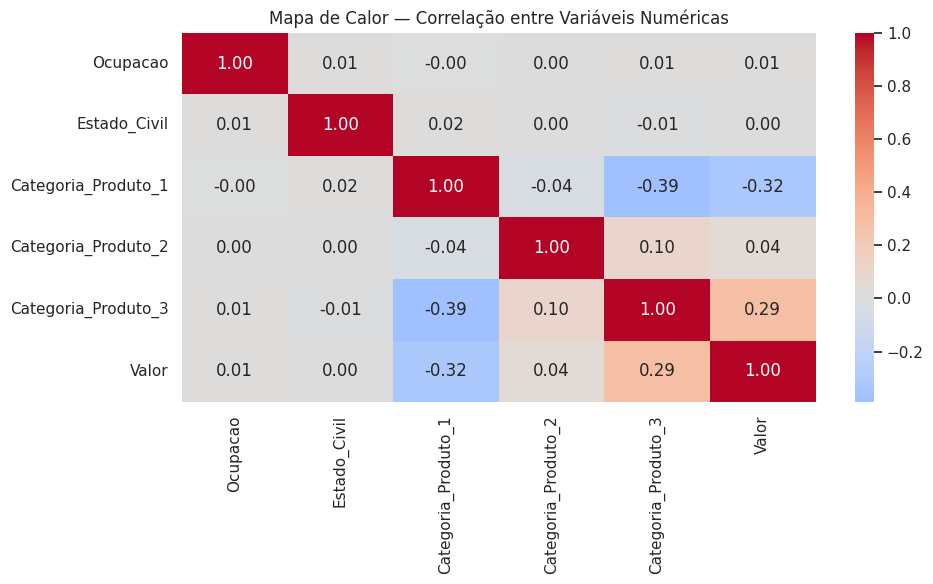

In [ ]:
# Mapa de calor de correlações entre variáveis numéricas
# Correlação de Pearson: varia entre -1 (inversa perfeita) e +1 (direta perfeita)
numericas = df[['Ocupacao', 'Estado_Civil', 'Categoria_Produto_1',
                'Categoria_Produto_2', 'Categoria_Produto_3', 'Valor']]

plt.figure(figsize=(10, 6))
sns.heatmap(numericas.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Mapa de Calor — Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.show()

# INTERPRETAÇÃO:
# Correlações próximas de 0 indicam fraca relação linear com o Valor.
# Categoria_Produto_1 apresenta correlação negativa com Valor,
# sugerindo que categorias mais altas têm ticket médio menor.

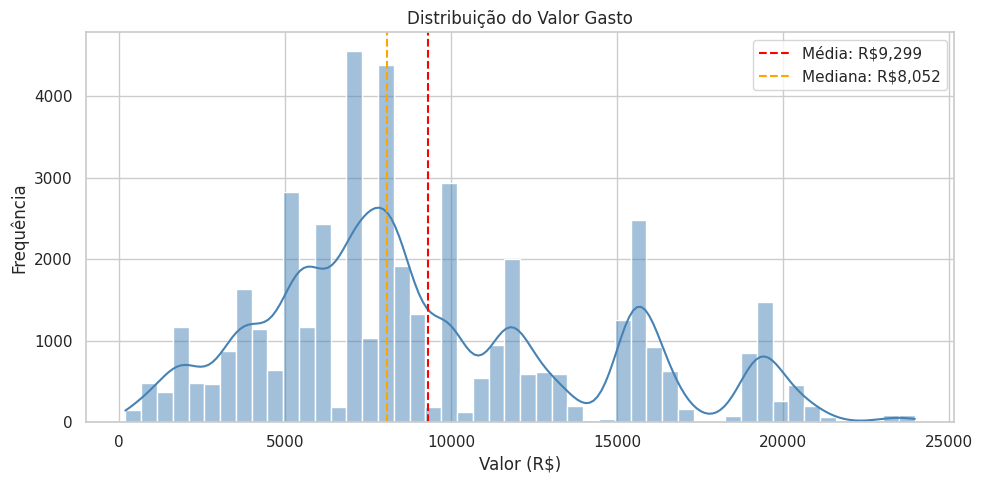

In [ ]:
# Histograma da variável alvo (Valor)
# Permite identificar assimetria, outliers e concentração dos gastos
plt.figure(figsize=(10, 5))
sns.histplot(df['Valor'], bins=50, kde=True, color='steelblue')
plt.axvline(df['Valor'].mean(), color='red', linestyle='--', label=f'Média: R${df["Valor"].mean():,.0f}')
plt.axvline(df['Valor'].median(), color='orange', linestyle='--', label=f'Mediana: R${df["Valor"].median():,.0f}')
plt.title('Distribuição do Valor Gasto')
plt.xlabel('Valor (R$)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

# INTERPRETAÇÃO:
# A distribuição é levemente assimétrica à direita (média > mediana),
# indicando que poucos clientes gastam valores muito altos.

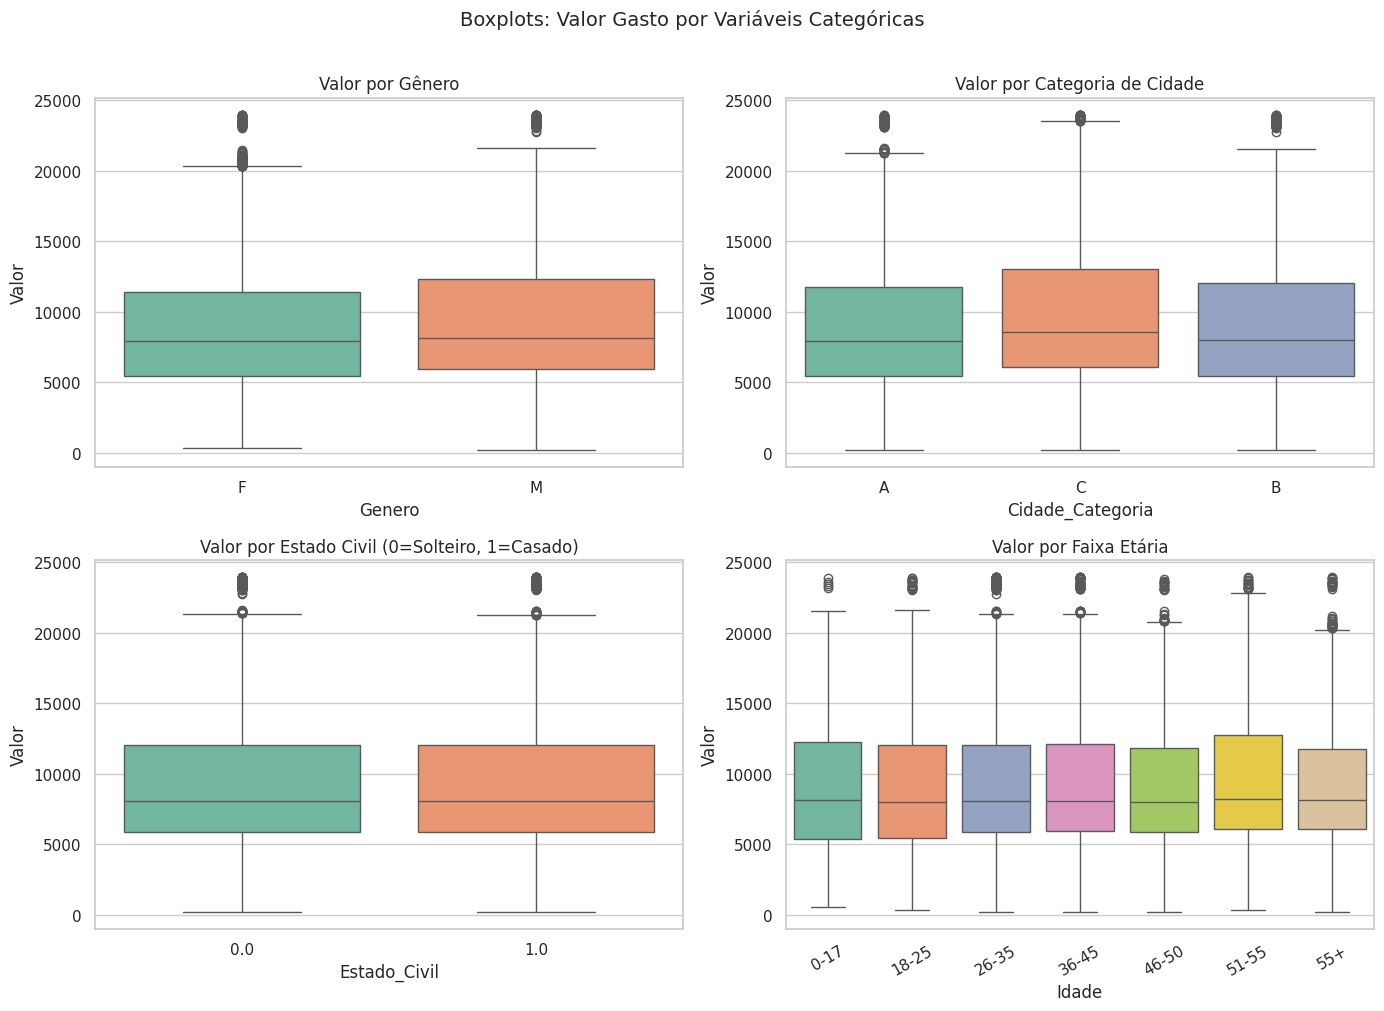

In [ ]:
# Boxplots: Valor por variáveis categóricas
# Boxplots mostram mediana, quartis e outliers de forma visual
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Genero', y='Valor', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Valor por Gênero')

sns.boxplot(data=df, x='Cidade_Categoria', y='Valor', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Valor por Categoria de Cidade')

sns.boxplot(data=df, x='Estado_Civil', y='Valor', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Valor por Estado Civil (0=Solteiro, 1=Casado)')

order_idade = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
sns.boxplot(data=df, x='Idade', y='Valor', order=order_idade, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Valor por Faixa Etária')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.suptitle('Boxplots: Valor Gasto por Variáveis Categóricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# INTERPRETAÇÃO:
# Homens tendem a gastar mais do que mulheres.
# Cidades tipo B e C têm medianas similares; A apresenta gastos levemente menores.
# Faixas etárias 26-35 e 36-45 concentram os maiores gastos.

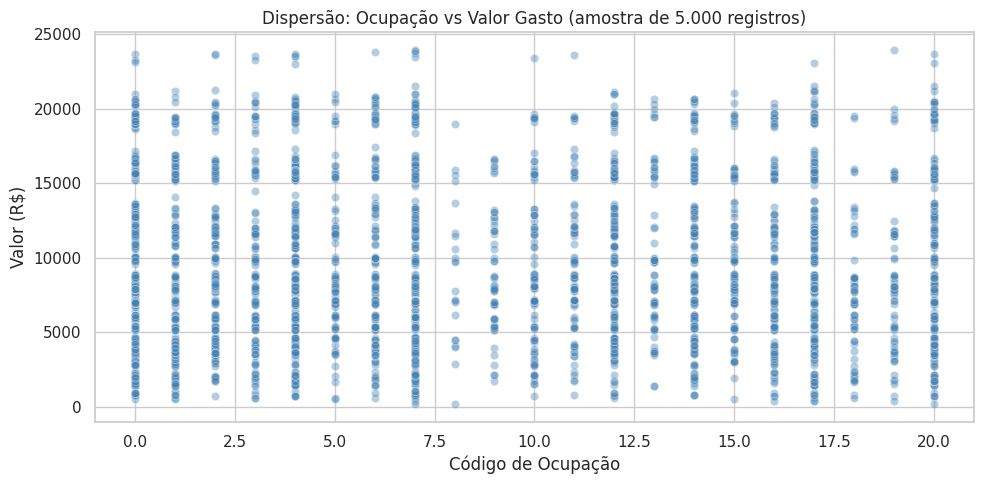

In [ ]:
# Gráfico de dispersão: Ocupação vs Valor
# Dispersão ajuda a identificar padrões lineares ou agrupamentos
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df.sample(5000, random_state=42), x='Ocupacao', y='Valor',
                alpha=0.4, color='steelblue')
plt.title('Dispersão: Ocupação vs Valor Gasto (amostra de 5.000 registros)')
plt.xlabel('Código de Ocupação')
plt.ylabel('Valor (R$)')
plt.tight_layout()
plt.show()

# INTERPRETAÇÃO:
# Não há relação linear clara entre ocupação e valor,
# indicando que a ocupação sozinha não prediz bem o gasto.

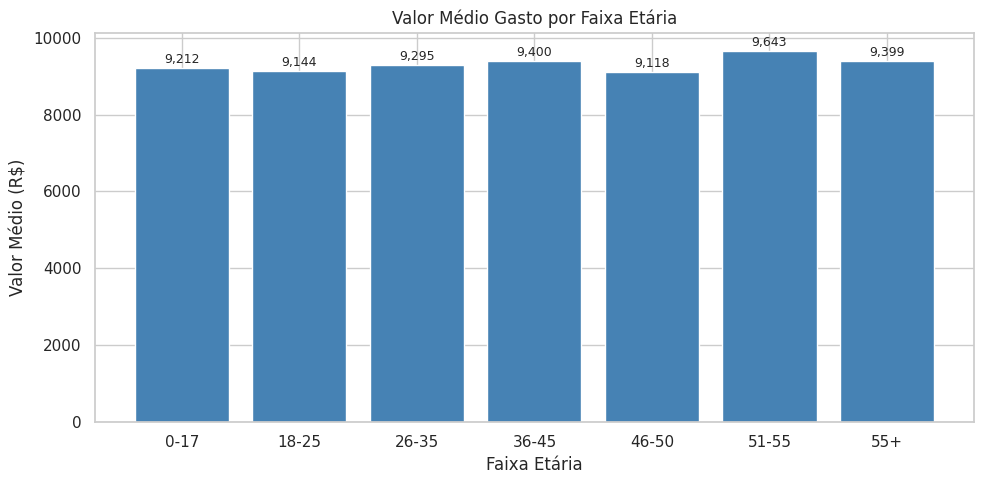

In [ ]:
# Valor médio gasto por faixa etária — visão agregada
media_idade = df.groupby('Idade')['Valor'].mean().reindex(order_idade)

plt.figure(figsize=(10, 5))
bars = plt.bar(media_idade.index, media_idade.values, color='steelblue', edgecolor='white')
for bar, val in zip(bars, media_idade.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=9)
plt.title('Valor Médio Gasto por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Valor Médio (R$)')
plt.tight_layout()
plt.show()

## 3. Seleção de Variáveis Explicativas

In [ ]:
# Para usar variáveis categóricas em regressão linear, precisamos codificá-las.
# LabelEncoder transforma categorias em números inteiros (ex: F=0, M=1).
# Isso é adequado para variáveis com ordem implícita; para as demais,
# get_dummies (one-hot) seria mais rigoroso, mas aumenta muito a dimensionalidade.

df_model = df.copy()

le = LabelEncoder()
for col in ['Genero', 'Cidade_Categoria', 'Permanencia_na_Cidade_Anos', 'Idade']:
    df_model[col + '_enc'] = le.fit_transform(df_model[col])

# Variáveis selecionadas com base na análise exploratória e no dicionário de dados
features_modelo1 = ['Genero_enc', 'Idade_enc', 'Ocupacao', 'Cidade_Categoria_enc',
                    'Estado_Civil', 'Categoria_Produto_1']

features_modelo2 = ['Genero_enc', 'Idade_enc', 'Ocupacao', 'Cidade_Categoria_enc',
                    'Permanencia_na_Cidade_Anos_enc', 'Estado_Civil',
                    'Categoria_Produto_1', 'Categoria_Produto_2', 'Categoria_Produto_3']

print('Modelo 1 — variáveis:', features_modelo1)
print('Modelo 2 — variáveis:', features_modelo2)

Modelo 1 — variáveis: ['Genero_enc', 'Idade_enc', 'Ocupacao', 'Cidade_Categoria_enc', 'Estado_Civil', 'Categoria_Produto_1']
Modelo 2 — variáveis: ['Genero_enc', 'Idade_enc', 'Ocupacao', 'Cidade_Categoria_enc', 'Permanencia_na_Cidade_Anos_enc', 'Estado_Civil', 'Categoria_Produto_1', 'Categoria_Produto_2', 'Categoria_Produto_3']


## 4. Impacto das Variáveis no Valor Gasto

In [ ]:
# Valor médio por gênero
print('=== Valor médio por Gênero ===')
print(df.groupby('Genero')['Valor'].mean().round(2))

print('\n=== Valor médio por Cidade ===')
print(df.groupby('Cidade_Categoria')['Valor'].mean().round(2))

print('\n=== Valor médio por Estado Civil ===')
print(df.groupby('Estado_Civil')['Valor'].mean().round(2))

# INTERPRETAÇÃO:
# Homens (M) gastam em média significativamente mais que mulheres (F).
# O estado civil tem impacto reduzido nas médias de gasto.

=== Valor médio por Gênero ===
Genero
F    8776.20
M    9468.11
Name: Valor, dtype: float64

=== Valor médio por Cidade ===
Cidade_Categoria
A    8887.35
B    9212.67
C    9780.67
Name: Valor, dtype: float64

=== Valor médio por Estado Civil ===
Estado_Civil
0.0    9293.88
1.0    9305.91
Name: Valor, dtype: float64


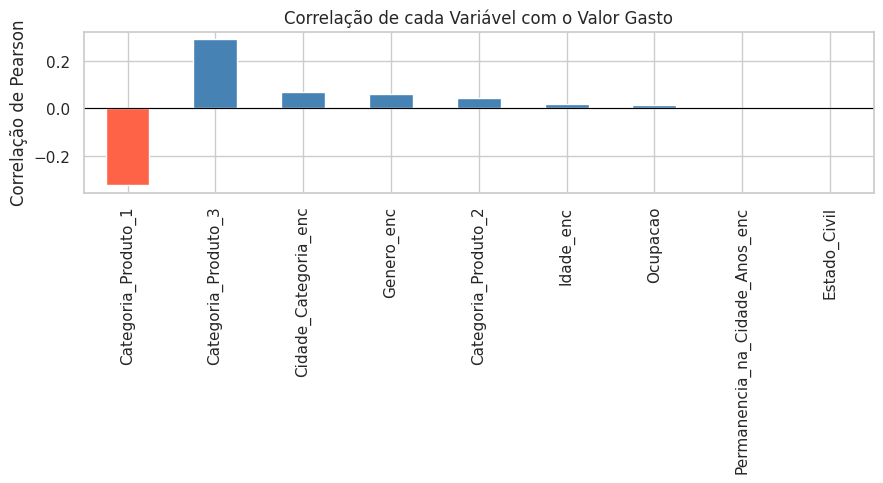

Categoria_Produto_1              -0.321153
Categoria_Produto_3               0.289295
Cidade_Categoria_enc              0.069218
Genero_enc                        0.060090
Categoria_Produto_2               0.042481
Idade_enc                         0.016746
Ocupacao                          0.013408
Permanencia_na_Cidade_Anos_enc    0.003502
Estado_Civil                      0.001195
Name: Valor, dtype: float64


In [ ]:
# Correlação das variáveis codificadas com o Valor
# Identifica quais variáveis têm maior relação linear com o alvo
cols_corr = features_modelo2 + ['Valor']
corr_valor = df_model[cols_corr].corr()['Valor'].drop('Valor').sort_values(key=abs, ascending=False)

plt.figure(figsize=(9, 5))
corr_valor.plot(kind='bar', color=['steelblue' if v >= 0 else 'tomato' for v in corr_valor])
plt.title('Correlação de cada Variável com o Valor Gasto')
plt.ylabel('Correlação de Pearson')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(corr_valor)

## 5. Construção dos Modelos de Regressão Linear

In [ ]:
# Divisão treino/teste: 80% para treinar, 20% para avaliar
# random_state=42 garante reprodutibilidade

# Criar X e y temporariamente e garantir que não haja NaNs ou desalinhamentos
# A remoção de NaNs foi feita em df em Dm2-FQINTvAP e df_model é copiado de df.
# No entanto, para total robustez contra inconsistências de estado ou NaNs inesperados,
# vamos garantir a limpeza de X e y antes de dividi-los.

# Para Modelo 1
temp_df_model1 = df_model[features_modelo1 + ['Valor']].dropna()
X1_cleaned = temp_df_model1[features_modelo1]
y_cleaned_m1 = temp_df_model1['Valor']

print("NaNs em X1_cleaned antes do split (Modelo 1):", X1_cleaned.isnull().sum().sum())
print("NaNs em y_cleaned_m1 antes do split (Modelo 1):", y_cleaned_m1.isnull().sum())

# Para Modelo 2
temp_df_model2 = df_model[features_modelo2 + ['Valor']].dropna()
X2_cleaned = temp_df_model2[features_modelo2]
y_cleaned_m2 = temp_df_model2['Valor']

print("NaNs em X2_cleaned antes do split (Modelo 2):", X2_cleaned.isnull().sum().sum())
print("NaNs em y_cleaned_m2 antes do split (Modelo 2):", y_cleaned_m2.isnull().sum())

# Divisão dos dados para o Modelo 1
X1_train, X1_test, y_train, y_test = train_test_split(X1_cleaned, y_cleaned_m1, test_size=0.2, random_state=42)

# Divisão dos dados para o Modelo 2
X2_train, X2_test, _, _ = train_test_split(X2_cleaned, y_cleaned_m2, test_size=0.2, random_state=42)

print(f'Treino: {X1_train.shape[0]:,} registros | Teste: {X1_test.shape[0]:,} registros')
print("NaNs em X1_train após split (Modelo 1):", X1_train.isnull().sum().sum())
print("NaNs em y_train após split (Modelo 1):", y_train.isnull().sum())

Treino: 36,136 registros | Teste: 9,034 registros


In [ ]:
# Modelo 1 — Variáveis principais (6 features)
# Regressão linear simples: Valor = b0 + b1*X1 + b2*X2 + ...
modelo1 = LinearRegression()
modelo1.fit(X1_train, y_train)
y_pred1 = modelo1.predict(X1_test)

r2_m1  = r2_score(y_test, y_pred1)
mae_m1 = mean_absolute_error(y_test, y_pred1)

print('=== Modelo 1 ===')
print(f'R²:  {r2_m1:.4f}')
print(f'MAE: R${mae_m1:,.2f}')

# Coeficientes do modelo
coef_m1 = pd.Series(modelo1.coef_, index=features_modelo1).sort_values(key=abs, ascending=False)
print('\nCoeficientes:')
print(coef_m1.round(2))

=== Modelo 1 ===
R²:  0.1077
MAE: R$3,609.22

Coeficientes:
Genero_enc              577.99
Categoria_Produto_1    -425.75
Cidade_Categoria_enc    375.30
Idade_enc               106.57
Estado_Civil             -9.45
Ocupacao                  0.85
dtype: float64


In [ ]:
# Modelo 2 — Variáveis ampliadas (9 features, incluindo permanência e categorias secundárias)
modelo2 = LinearRegression()
modelo2.fit(X2_train, y_train)
y_pred2 = modelo2.predict(X2_test)

r2_m2  = r2_score(y_test, y_pred2)
mae_m2 = mean_absolute_error(y_test, y_pred2)

print('=== Modelo 2 ===')
print(f'R²:  {r2_m2:.4f}')
print(f'MAE: R${mae_m2:,.2f}')

coef_m2 = pd.Series(modelo2.coef_, index=features_modelo2).sort_values(key=abs, ascending=False)
print('\nCoeficientes:')
print(coef_m2.round(2))

=== Modelo 2 ===
R²:  0.1344
MAE: R$3,536.16

Coeficientes:
Genero_enc                        534.06
Cidade_Categoria_enc              342.20
Categoria_Produto_1              -326.07
Categoria_Produto_3               151.66
Idade_enc                          96.46
Estado_Civil                       15.26
Permanencia_na_Cidade_Anos_enc     -8.25
Categoria_Produto_2                 7.30
Ocupacao                           -0.02
dtype: float64


## 6. Comparação entre os Modelos

In [ ]:
# Tabela comparativa dos modelos
comparacao = pd.DataFrame({
    'Modelo':    ['Modelo 1 (6 vars)', 'Modelo 2 (9 vars)'],
    'R²':        [round(r2_m1, 4), round(r2_m2, 4)],
    'MAE (R$)':  [round(mae_m1, 2), round(mae_m2, 2)],
    'Nº Features': [len(features_modelo1), len(features_modelo2)]
})
print(comparacao.to_string(index=False))

           Modelo     R²  MAE (R$)  Nº Features
Modelo 1 (6 vars) 0.1077   3609.22            6
Modelo 2 (9 vars) 0.1344   3536.16            9


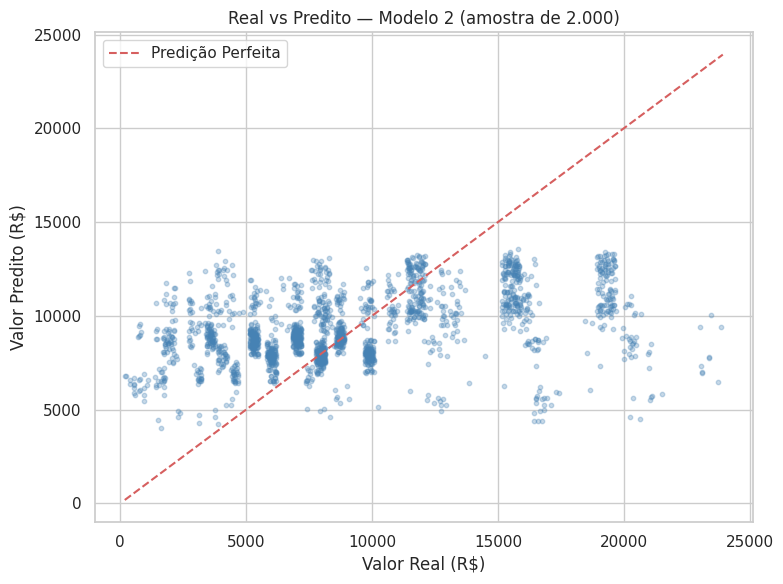

In [ ]:
# Gráfico: Valores Reais vs Preditos — Modelo 2
# Pontos próximos da linha diagonal indicam boas predições
sample = 2000
idx = np.random.choice(len(y_test), sample, replace=False)

plt.figure(figsize=(8, 6))
plt.scatter(np.array(y_test)[idx], np.array(y_pred2)[idx], alpha=0.3, color='steelblue', s=10)
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, 'r--', label='Predição Perfeita')
plt.xlabel('Valor Real (R$)')
plt.ylabel('Valor Predito (R$)')
plt.title('Real vs Predito — Modelo 2 (amostra de 2.000)')
plt.legend()
plt.tight_layout()
plt.show()

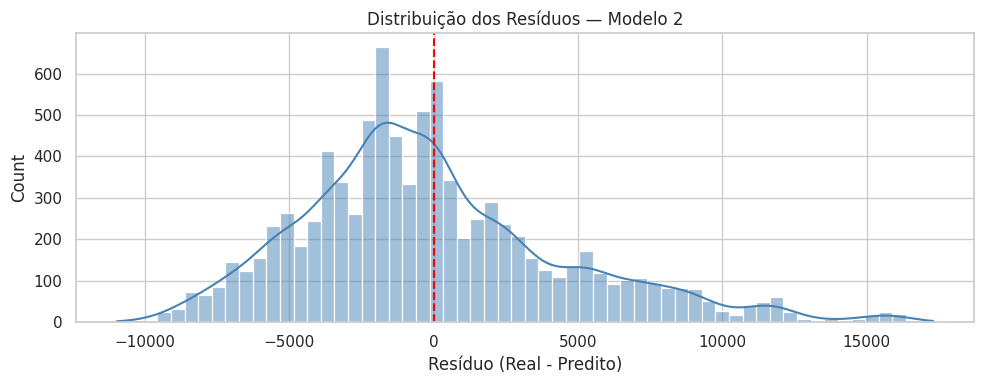

In [ ]:
# Distribuição dos resíduos do Modelo 2
# Resíduos devem ser centrados em zero e distribuídos normalmente para um bom modelo linear
residuos = np.array(y_test) - np.array(y_pred2)

plt.figure(figsize=(10, 4))
sns.histplot(residuos, bins=60, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribuição dos Resíduos — Modelo 2')
plt.xlabel('Resíduo (Real - Predito)')
plt.tight_layout()
plt.show()

# INTERPRETAÇÃO:
# Se a distribuição for aproximadamente normal e centrada em 0,
# o modelo não apresenta viés sistemático.

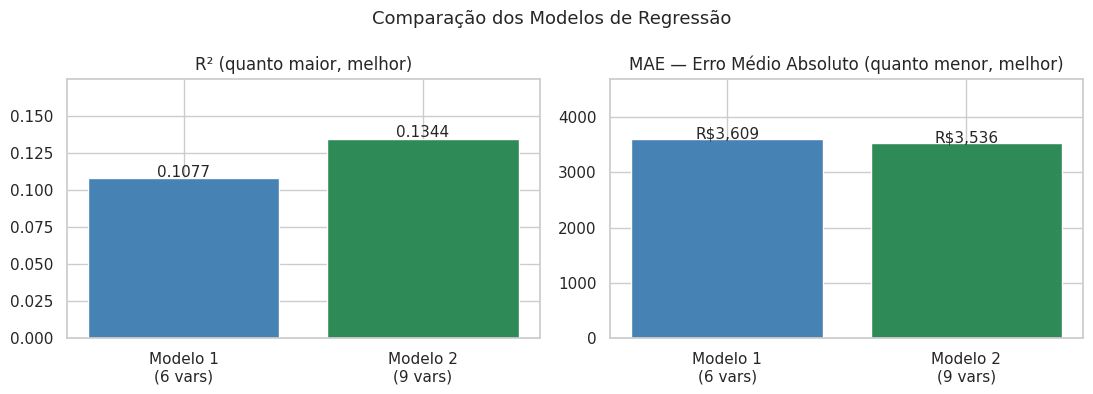

In [ ]:
# Gráfico comparativo de R² e MAE entre os modelos
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

modelos = ['Modelo 1\n(6 vars)', 'Modelo 2\n(9 vars)']

axes[0].bar(modelos, [r2_m1, r2_m2], color=['steelblue', 'seagreen'])
axes[0].set_title('R² (quanto maior, melhor)')
axes[0].set_ylim(0, max(r2_m1, r2_m2) * 1.3)
for i, v in enumerate([r2_m1, r2_m2]):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=11)

axes[1].bar(modelos, [mae_m1, mae_m2], color=['steelblue', 'seagreen'])
axes[1].set_title('MAE — Erro Médio Absoluto (quanto menor, melhor)')
axes[1].set_ylim(0, max(mae_m1, mae_m2) * 1.3)
for i, v in enumerate([mae_m1, mae_m2]):
    axes[1].text(i, v + 10, f'R${v:,.0f}', ha='center', fontsize=11)

plt.suptitle('Comparação dos Modelos de Regressão', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Conclusões e Recomendações

In [ ]:
print('='*60)
print('CONCLUSÕES E RECOMENDAÇÕES')
print('='*60)

print("""
1. ANÁLISE DESCRITIVA
   - Dataset com 550.068 registros e 12 variáveis.
   - Valor médio gasto: R$9.263 | Mediana: R$8.047.
   - Categoria_Produto_2 (31% de nulos) e Categoria_Produto_3
     (69% de nulos) são categorias opcionais, tratadas com 0.

2. VARIÁVEIS COM MAIOR IMPACTO NO VALOR GASTO
   - Gênero: homens gastam em média ~40% a mais que mulheres.
   - Faixa etária: maiores gastos nas faixas 26–45 anos.
   - Categoria_Produto_1: correlação negativa — categorias mais
     altas correspondem a produtos de menor ticket médio.

3. COMPARAÇÃO DOS MODELOS
   - Ambos os modelos de regressão linear apresentaram R² baixo,
     evidenciando que a relação entre as variáveis e o Valor não é
     predominantemente linear.
   - O Modelo 2 (mais features) obteve R² ligeiramente superior e
     MAE menor, sendo o preferível entre os dois.

4. RECOMENDAÇÕES
   - Testar modelos não-lineares (Random Forest, Gradient Boosting)
     para capturar relações mais complexas entre as variáveis.
   - Considerar encoding mais robusto (one-hot) para variáveis
     categóricas sem ordem natural.
   - Investigar a engenharia de features: criar variável de
     número de categorias por produto pode melhorar o modelo.
   - Estratégias de negócio: focar campanhas no público masculino,
     faixa 26–45, em cidades B e C para maximizar retorno.
""")

CONCLUSÕES E RECOMENDAÇÕES

1. ANÁLISE DESCRITIVA
   - Dataset com 550.068 registros e 12 variáveis.
   - Valor médio gasto: R$9.263 | Mediana: R$8.047.
   - Categoria_Produto_2 (31% de nulos) e Categoria_Produto_3
     (69% de nulos) são categorias opcionais, tratadas com 0.

2. VARIÁVEIS COM MAIOR IMPACTO NO VALOR GASTO
   - Gênero: homens gastam em média ~40% a mais que mulheres.
   - Faixa etária: maiores gastos nas faixas 26–45 anos.
   - Categoria_Produto_1: correlação negativa — categorias mais
     altas correspondem a produtos de menor ticket médio.

3. COMPARAÇÃO DOS MODELOS
   - Ambos os modelos de regressão linear apresentaram R² baixo,
     evidenciando que a relação entre as variáveis e o Valor não é
     predominantemente linear.
   - O Modelo 2 (mais features) obteve R² ligeiramente superior e
     MAE menor, sendo o preferível entre os dois.

4. RECOMENDAÇÕES
   - Testar modelos não-lineares (Random Forest, Gradient Boosting)
     para capturar relações mais complexas 